# Segmentación automática de estructuras dentales en radiografías panorámicas

Este notebook implementa un modelo de segmentación semántica basado en U-Net para identificar estructuras dentales en radiografías panorámicas.

El flujo general incluye:

1. Carga del dataset con anotaciones en formato COCO.
2. Conversión de anotaciones a máscaras binarias.
3. Preprocesamiento de imágenes.
4. Entrenamiento de una arquitectura U-Net.
5. Evaluación mediante Dice, IoU y Loss.
6. Visualización de resultados.
7. Validación con imágenes externas.

Resultados reportados:

- Dice: 0.849
- IoU: 0.737
- Loss: 0.151

## 1. Configuración e importación de librerías

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Modificar dependiendo de la locación del dataset
DATASET_PATH = "/content/drive/MyDrive/DentalDataset/PanoramicDentalXrayDataset/Secondpart"

TRAIN_PATH = f"{DATASET_PATH}/train"
VALID_PATH = f"{DATASET_PATH}/valid"
TEST_PATH  = f"{DATASET_PATH}/test"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Instalar dependencias necesarias en Google Colab
!pip install pycocotools opencv-python -q

In [5]:
import os
import cv2
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from pycocotools.coco import COCO

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    concatenate
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Configuración general

In [6]:
# Semilla para reproducibilidad
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dimensiones de entrada del modelo
IMG_HEIGHT = 512
IMG_WIDTH = 1024
IMG_CHANNELS = 1

# Parámetros de entrenamiento
BATCH_SIZE = 2
EPOCHS = 60
LEARNING_RATE = 1e-4

# Umbral para convertir probabilidades en máscara binaria
THRESHOLD = 0.5

# Montar google drive y rutas del dataset

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Modificar esta ruta dependiendo de la ubicación del dataset en Google Drive
DATASET_PATH = "/content/drive/MyDrive/DentalDataset/PanoramicDentalXrayDataset/Secondpart"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VALID_PATH = os.path.join(DATASET_PATH, "valid")
TEST_PATH = os.path.join(DATASET_PATH, "test")

print("Train path:", TRAIN_PATH)
print("Valid path:", VALID_PATH)
print("Test path:", TEST_PATH)

Train path: /content/drive/MyDrive/DentalDataset/PanoramicDentalXrayDataset/Secondpart/train
Valid path: /content/drive/MyDrive/DentalDataset/PanoramicDentalXrayDataset/Secondpart/valid
Test path: /content/drive/MyDrive/DentalDataset/PanoramicDentalXrayDataset/Secondpart/test


# Exploración dataset

In [9]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO

# Ajusta esta ruta si tu carpeta tiene otro nombre
DATASET_PATH = "/content/drive/MyDrive/DentalDataset/PanoramicDentalXrayDataset/Secondpart"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
TRAIN_IMG_PATH = os.path.join(TRAIN_PATH, "imgs")
TRAIN_ANN_PATH = os.path.join(TRAIN_PATH, "_annotations.coco.json")

# Si tu archivo no tiene guion bajo, usa esta alternativa automática
if not os.path.exists(TRAIN_ANN_PATH):
    TRAIN_ANN_PATH = os.path.join(TRAIN_PATH, "annotations.coco.json")

print("Ruta imágenes:", TRAIN_IMG_PATH)
print("Ruta anotaciones:", TRAIN_ANN_PATH)

print("Existe carpeta imgs:", os.path.exists(TRAIN_IMG_PATH))
print("Existe archivo JSON:", os.path.exists(TRAIN_ANN_PATH))

coco = COCO(TRAIN_ANN_PATH)

print("Número de imágenes:", len(coco.imgs))
print("Número de anotaciones:", len(coco.anns))
print("Categorías:")
for cat in coco.loadCats(coco.getCatIds()):
    print(cat["id"], cat["name"])

Ruta imágenes: /content/drive/MyDrive/DentalDataset/PanoramicDentalXrayDataset/Secondpart/train/imgs
Ruta anotaciones: /content/drive/MyDrive/DentalDataset/PanoramicDentalXrayDataset/Secondpart/train/_annotations.coco.json
Existe carpeta imgs: True
Existe archivo JSON: True
loading annotations into memory...
Done (t=2.28s)
creating index...
index created!
Número de imágenes: 42
Número de anotaciones: 1255
Categorías:
0 dental
1 canine
2 central incisor
3 first molar
4 first premolar
5 lateral incisor
6 second molar
7 second premolar
8 third molar


# Visualización imagen y máscara COCO

In [10]:
# Ruta de entrenamiento
TRAIN_IMG_PATH = os.path.join(TRAIN_PATH, "imgs")
TRAIN_ANN_PATH = os.path.join(TRAIN_PATH, "_annotations.coco.json")

# Alternativa por si el archivo tiene otro nombre
if not os.path.exists(TRAIN_ANN_PATH):
    TRAIN_ANN_PATH = os.path.join(TRAIN_PATH, "annotations.coco.json")

print("Ruta imágenes:", TRAIN_IMG_PATH)
print("Ruta anotaciones:", TRAIN_ANN_PATH)

coco = COCO(TRAIN_ANN_PATH)

print("\nNúmero de imágenes:", len(coco.imgs))
print("Número de anotaciones:", len(coco.anns))

print("\nCategorías:")
for cat in coco.loadCats(coco.getCatIds()):
    print(cat["id"], cat["name"])

Ruta imágenes: /content/drive/MyDrive/DentalDataset/PanoramicDentalXrayDataset/Secondpart/train/imgs
Ruta anotaciones: /content/drive/MyDrive/DentalDataset/PanoramicDentalXrayDataset/Secondpart/train/_annotations.coco.json
loading annotations into memory...
Done (t=0.10s)
creating index...
index created!

Número de imágenes: 42
Número de anotaciones: 1255

Categorías:
0 dental
1 canine
2 central incisor
3 first molar
4 first premolar
5 lateral incisor
6 second molar
7 second premolar
8 third molar


In [11]:
# Seleccionar una imagen de ejemplo
img_id = list(coco.imgs.keys())[0]
img_info = coco.loadImgs(img_id)[0]

img_path = os.path.join(TRAIN_IMG_PATH, img_info["file_name"])
image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)

# Crear máscara binaria
mask = np.zeros(
    (img_info["height"], img_info["width"]),
    dtype=np.uint8
)

for ann in anns:
    ann_mask = coco.annToMask(ann)
    mask = np.maximum(mask, ann_mask)

print("Imagen:", img_info["file_name"])
print("Tamaño imagen:", image.shape)
print("Tamaño máscara:", mask.shape)
print("Número de anotaciones:", len(anns))
print("Valores únicos en máscara:", np.unique(mask))

Imagen: 50_jpg.rf.05c0b85f55fbb2f21845270ebeb3f615.jpg
Tamaño imagen: (512, 1024)
Tamaño máscara: (512, 1024)
Número de anotaciones: 30
Valores únicos en máscara: [0 1]


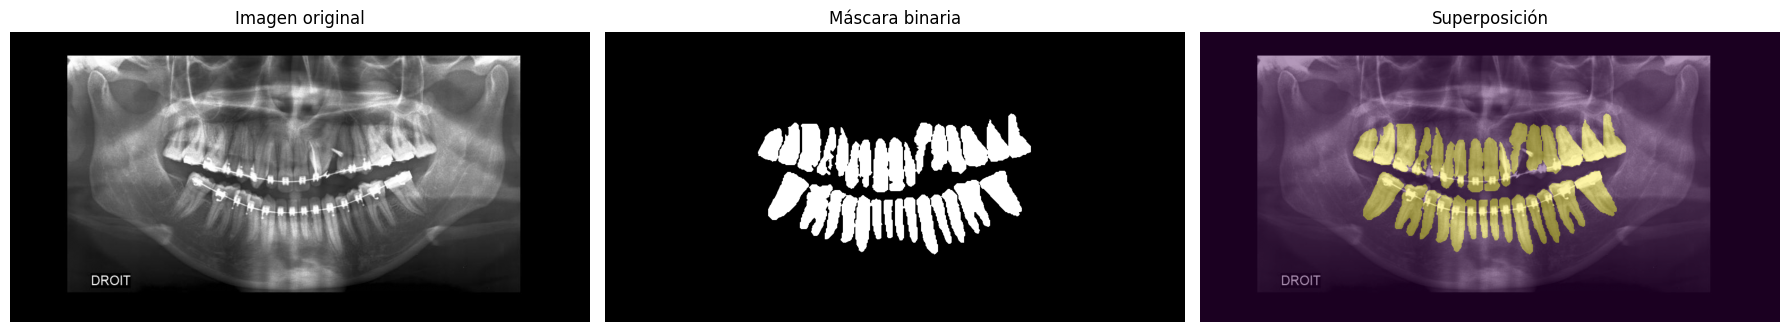

In [12]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Máscara binaria")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image, cmap="gray")
plt.imshow(mask, alpha=0.4)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

# Carga y preprocesamiento del dataset

In [13]:
def load_dataset(split_path):
    """
    Carga imágenes y anotaciones COCO de un subconjunto del dataset.
    Convierte las anotaciones en máscaras binarias y redimensiona las imágenes.
    """

    img_dir = os.path.join(split_path, "imgs")
    ann_path = os.path.join(split_path, "_annotations.coco.json")

    if not os.path.exists(ann_path):
        ann_path = os.path.join(split_path, "annotations.coco.json")

    coco = COCO(ann_path)

    X = []
    Y = []

    for img_id in coco.imgs.keys():

        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, img_info["file_name"])

        # Leer imagen en escala de grises
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # Redimensionar imagen
        image = cv2.resize(
            image,
            (IMG_WIDTH, IMG_HEIGHT)
        )

        # Normalizar intensidades al rango [0,1]
        image = image.astype(np.float32) / 255.0

        # Crear máscara binaria
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        mask = np.zeros(
            (img_info["height"], img_info["width"]),
            dtype=np.uint8
        )

        for ann in anns:
            ann_mask = coco.annToMask(ann)
            mask = np.maximum(mask, ann_mask)

        # Redimensionar máscara sin interpolación suave
        mask = cv2.resize(
            mask,
            (IMG_WIDTH, IMG_HEIGHT),
            interpolation=cv2.INTER_NEAREST
        )

        X.append(image)
        Y.append(mask)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

    # Agregar canal: (N, H, W, 1)
    X = np.expand_dims(X, axis=-1)
    Y = np.expand_dims(Y, axis=-1)

    return X, Y

In [14]:
print("Cargando datasets...")

X_train, Y_train = load_dataset(TRAIN_PATH)
X_valid, Y_valid = load_dataset(VALID_PATH)
X_test, Y_test = load_dataset(TEST_PATH)

print("Train:", X_train.shape, Y_train.shape)
print("Valid:", X_valid.shape, Y_valid.shape)
print("Test :", X_test.shape, Y_test.shape)

Cargando datasets...
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.87s)
creating index...
index created!
loading annotations into memory...
Done (t=0.89s)
creating index...
index created!
Train: (42, 512, 1024, 1) (42, 512, 1024, 1)
Valid: (12, 512, 1024, 1) (12, 512, 1024, 1)
Test : (6, 512, 1024, 1) (6, 512, 1024, 1)


# Visualización de ejemplos preprocesados

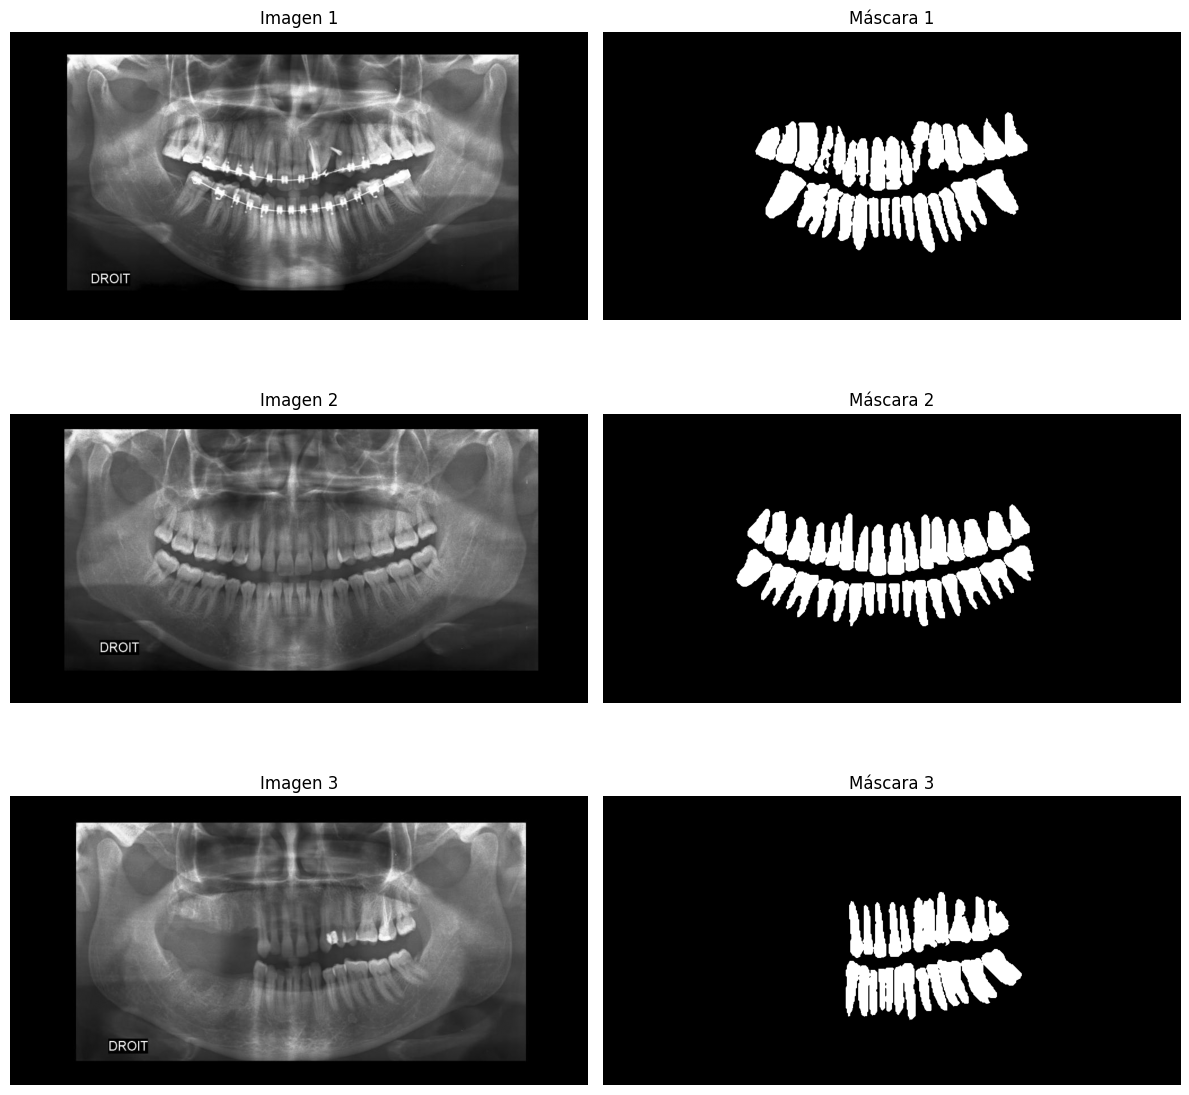

In [15]:
num_examples = min(3, len(X_train))

fig, axes = plt.subplots(num_examples, 2, figsize=(12, 12))

for i in range(num_examples):

    axes[i, 0].imshow(X_train[i].squeeze(), cmap="gray")
    axes[i, 0].set_title(f"Imagen {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(Y_train[i].squeeze(), cmap="gray")
    axes[i, 1].set_title(f"Máscara {i+1}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

# Métricas de evaluación

In [16]:
def dice_coefficient_tf(y_true, y_pred, smooth=1e-6):
    """
    Calcula el coeficiente Dice entre la máscara real y la máscara predicha.
    """

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    dice = (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) +
        tf.reduce_sum(y_pred_f) +
        smooth
    )

    return dice


def dice_loss_tf(y_true, y_pred):
    """
    Función de pérdida basada en Dice.
    """

    return 1.0 - dice_coefficient_tf(y_true, y_pred)


def iou_metric_tf(y_true, y_pred, smooth=1e-6):
    """
    Calcula Intersection over Union entre máscara real y predicción.
    """

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    union = (
        tf.reduce_sum(y_true_f) +
        tf.reduce_sum(y_pred_f) -
        intersection
    )

    iou = (intersection + smooth) / (union + smooth)

    return iou

# Arquitectura U-Net

In [17]:
def build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    """
    Construye una arquitectura U-Net para segmentación semántica binaria.
    """

    inputs = Input(input_shape)

    # Encoder 1
    c1 = Conv2D(32, 3, activation="relu", padding="same")(inputs)
    c1 = Conv2D(32, 3, activation="relu", padding="same")(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    # Encoder 2
    c2 = Conv2D(64, 3, activation="relu", padding="same")(p1)
    c2 = Conv2D(64, 3, activation="relu", padding="same")(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # Encoder 3
    c3 = Conv2D(128, 3, activation="relu", padding="same")(p2)
    c3 = Conv2D(128, 3, activation="relu", padding="same")(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    # Bottleneck
    bn = Conv2D(256, 3, activation="relu", padding="same")(p3)
    bn = Conv2D(256, 3, activation="relu", padding="same")(bn)

    # Decoder 1
    u4 = UpSampling2D((2, 2))(bn)
    u4 = concatenate([u4, c3])

    c4 = Conv2D(128, 3, activation="relu", padding="same")(u4)
    c4 = Conv2D(128, 3, activation="relu", padding="same")(c4)

    # Decoder 2
    u5 = UpSampling2D((2, 2))(c4)
    u5 = concatenate([u5, c2])

    c5 = Conv2D(64, 3, activation="relu", padding="same")(u5)
    c5 = Conv2D(64, 3, activation="relu", padding="same")(c5)

    # Decoder 3
    u6 = UpSampling2D((2, 2))(c5)
    u6 = concatenate([u6, c1])

    c6 = Conv2D(32, 3, activation="relu", padding="same")(u6)
    c6 = Conv2D(32, 3, activation="relu", padding="same")(c6)

    # Salida binaria
    outputs = Conv2D(1, 1, activation="sigmoid")(c6)

    model = Model(inputs, outputs)

    return model

# Compilación del modelo

In [18]:
model = build_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=dice_loss_tf,
    metrics=[
        dice_coefficient_tf,
        iou_metric_tf
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 1024, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 1024, │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 1024, │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 512,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 512,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 512,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 256,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 256,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 256,  │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 128,   │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 128,   │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 128,   │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 256,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 256,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 256,  │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 256,  │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 512,  │          0 │ conv2d_9[0][0]  

 Total params: 1,946,305 (7.42 MB)

 Trainable params: 1,946,305 (7.42 MB)

 Non-trainable params: 0 (0.00 B)

# Callbacks de entrenamiento

In [19]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6
    ),

    ModelCheckpoint(
        "best_unet_dental.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [20]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_valid, Y_valid),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 43s 625ms/step - dice_coefficient_tf: 0.1928 - iou_metric_tf: 0.1080 - loss: 0.8072 - val_dice_coefficient_tf: 0.2270 - val_iou_metric_tf: 0.1281 - val_loss: 0.7730 - learning_rate: 1.0000e-04
Epoch 2/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 276ms/step - dice_coefficient_tf: 0.2380 - iou_metric_tf: 0.1382 - loss: 0.7620 - val_dice_coefficient_tf: 0.2422 - val_iou_metric_tf: 0.1379 - val_loss: 0.7578 - learning_rate: 1.0000e-04
Epoch 3/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 284ms/step - dice_coefficient_tf: 0.2893 - iou_metric_tf: 0.1734 - loss: 0.7107 - val_dice_coefficient_tf: 0.2987 - val_iou_metric_tf: 0.1758 - val_loss: 0.7013 - learning_rate: 1.0000e-04
Epoch 4/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 281ms/step - dice_coefficient_tf: 0.3483 - iou_metric_tf: 0.2172 - loss: 0.6517 - val_dice_coefficient_tf: 0.3720 - val_iou_metric_tf: 0.2291 - val_loss: 0.6280 - learning_rate: 1.0000e-04
Epoch 5/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 276ms/step - dice_coefficient_tf: 0.36

# Evaluación cuantitativa

In [21]:
results = model.evaluate(
    X_test,
    Y_test,
    verbose=1
)

test_loss = results[0]
test_dice = results[1]
test_iou = results[2]

print("\nRESULTADOS FINALES EN TEST")
print(f"Loss: {test_loss:.4f}")
print(f"Dice: {test_dice:.4f}")
print(f"IoU : {test_iou:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - dice_coefficient_tf: 0.8419 - iou_metric_tf: 0.7270 - loss: 0.1581

RESULTADOS FINALES EN TEST
Loss: 0.1581
Dice: 0.8419
IoU : 0.7270


# Curvas de entrenamiento

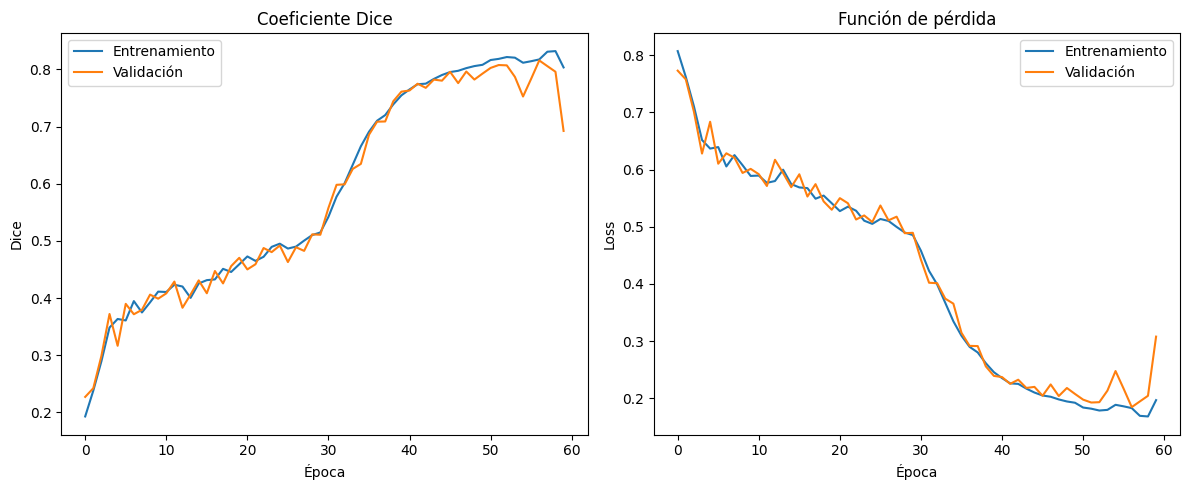

In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["dice_coefficient_tf"])
plt.plot(history.history["val_dice_coefficient_tf"])
plt.title("Coeficiente Dice")
plt.xlabel("Época")
plt.ylabel("Dice")
plt.legend(["Entrenamiento", "Validación"])

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Función de pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend(["Entrenamiento", "Validación"])

plt.tight_layout()
plt.savefig(
    "curvas_entrenamiento.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Resultados visuales en conjunto de prueba

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


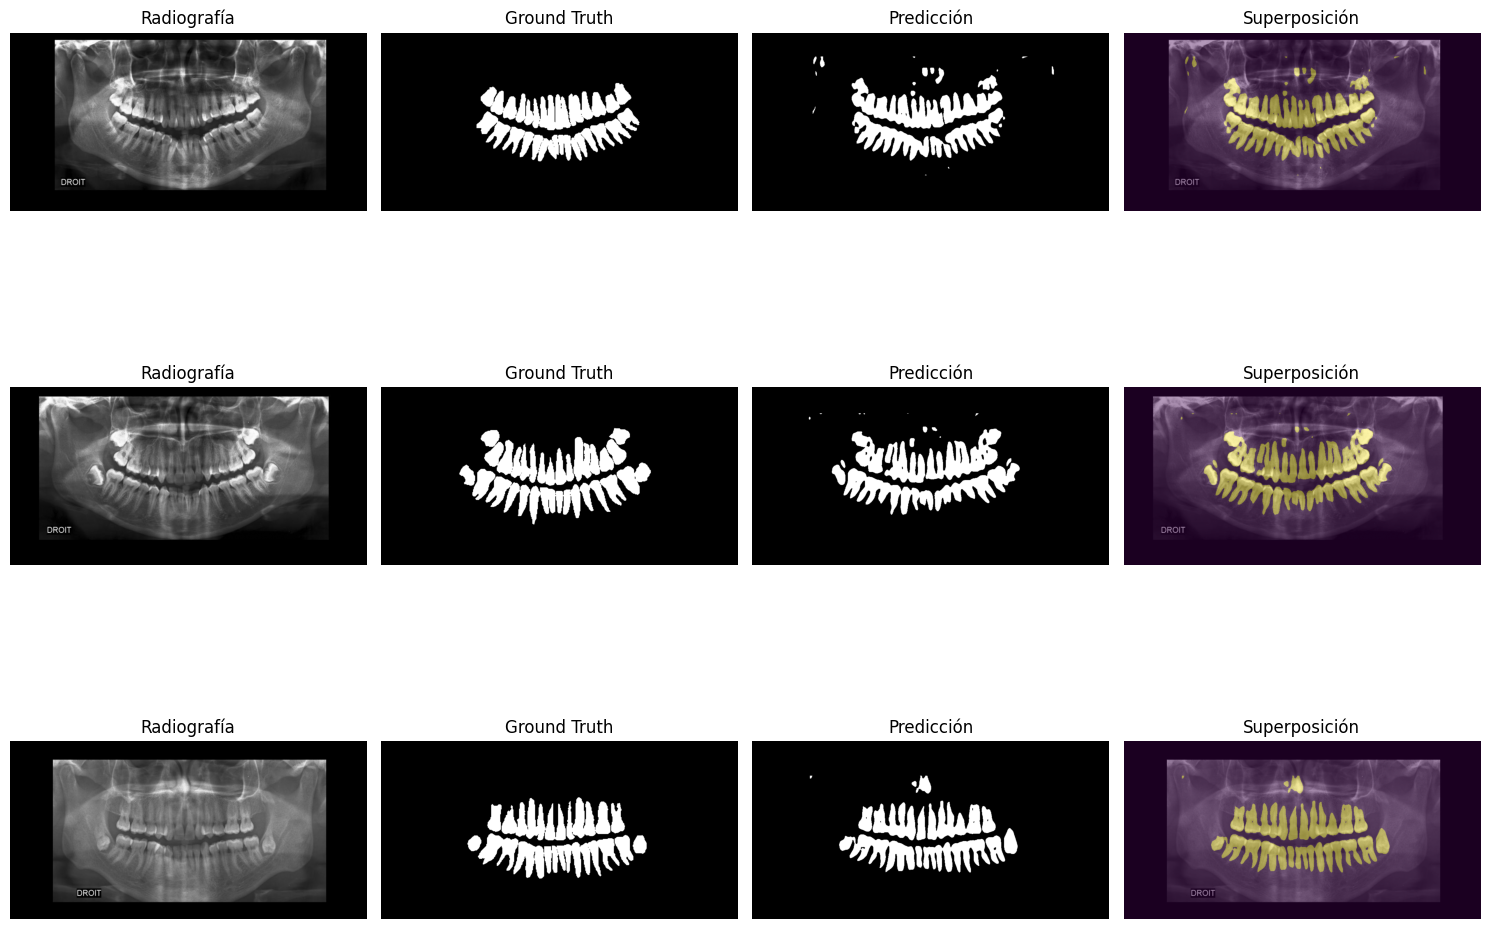

In [23]:
preds = model.predict(X_test)

num_samples = min(3, len(X_test))

plt.figure(figsize=(15, 12))

for i in range(num_samples):

    pred_mask = (preds[i] > THRESHOLD).astype(np.uint8)

    plt.subplot(num_samples, 4, i*4 + 1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.title("Radiografía")
    plt.axis("off")

    plt.subplot(num_samples, 4, i*4 + 2)
    plt.imshow(Y_test[i].squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_samples, 4, i*4 + 3)
    plt.imshow(pred_mask.squeeze(), cmap="gray")
    plt.title("Predicción")
    plt.axis("off")

    plt.subplot(num_samples, 4, i*4 + 4)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.imshow(pred_mask.squeeze(), alpha=0.4)
    plt.title("Superposición")
    plt.axis("off")

plt.tight_layout()
plt.savefig(
    "resultados_segmentacion_test.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Figura individual

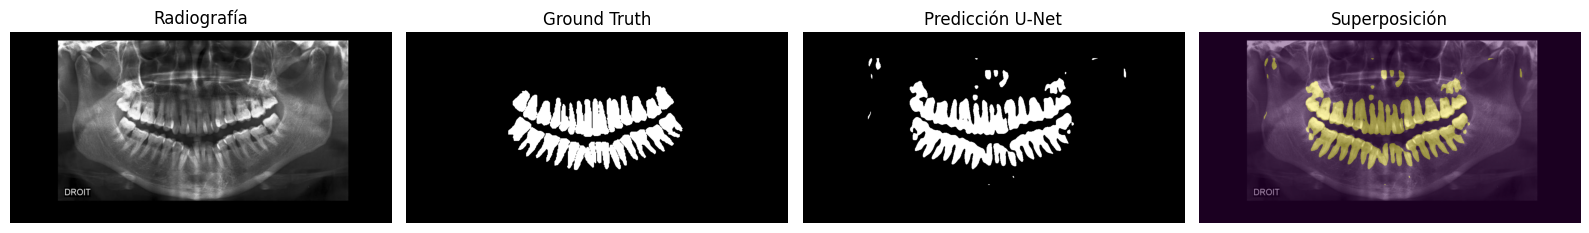

Figura guardada como: figura_segmentacion_unet.png


In [24]:
idx = 0

pred = model.predict(X_test[idx:idx+1], verbose=0)
pred_mask = (pred[0] > THRESHOLD).astype(np.uint8)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(X_test[idx].squeeze(), cmap="gray")
plt.title("Radiografía")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(Y_test[idx].squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_mask.squeeze(), cmap="gray")
plt.title("Predicción U-Net")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(X_test[idx].squeeze(), cmap="gray")
plt.imshow(pred_mask.squeeze(), alpha=0.4)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "figura_segmentacion_unet.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada como: figura_segmentacion_unet.png")

# Arquitectura del modelo

In [25]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="unet_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=300
)

print("Arquitectura guardada como: unet_architecture.png")

Arquitectura guardada como: unet_architecture.png


# Costo computacional

In [26]:
# Información de hardware
print("Dispositivos GPU disponibles:")
print(tf.config.list_physical_devices("GPU"))

Dispositivos GPU disponibles:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [27]:
# Número de parámetros del modelo
total_params = model.count_params()

print("Parámetros totales del modelo:", total_params)

Parámetros totales del modelo: 1946305


In [28]:
# Tiempo de inferencia para una imagen
start = time.time()

_ = model.predict(
    X_test[0:1],
    verbose=0
)

end = time.time()

inference_time = end - start

print(f"Tiempo de inferencia por imagen: {inference_time:.4f} segundos")

Tiempo de inferencia por imagen: 0.1315 segundos


In [29]:
# Tamaño aproximado del modelo guardado
model.save("best_unet_dental_final.keras")

model_size_mb = os.path.getsize("best_unet_dental_final.keras") / (1024 * 1024)

print(f"Tamaño aproximado del modelo: {model_size_mb:.2f} MB")

Tamaño aproximado del modelo: 22.38 MB


# Validación con imagen externa

In [30]:
from google.colab import files

print("Selecciona una radiografía panorámica externa")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Archivo cargado:", filename)

Selecciona una radiografía panorámica externa


Saving xraydental.jpg to xraydental.jpg
Archivo cargado: xraydental.jpg


In [31]:
# Leer imagen externa
image = cv2.imread(
    filename,
    cv2.IMREAD_GRAYSCALE
)

if image is None:
    raise ValueError("No se pudo cargar la imagen. Verifica el archivo.")

image_resized = cv2.resize(
    image,
    (IMG_WIDTH, IMG_HEIGHT)
)

image_norm = image_resized.astype(np.float32) / 255.0

image_input = np.expand_dims(
    image_norm,
    axis=(0, -1)
)

In [32]:
# Predicción
prediction = model.predict(
    image_input,
    verbose=0
)

pred_mask = (
    prediction[0] > THRESHOLD
).astype(np.uint8)

In [33]:
# Postprocesamiento morfológico
kernel = np.ones((3, 3), np.uint8)

pred_mask = cv2.morphologyEx(
    pred_mask,
    cv2.MORPH_OPEN,
    kernel
)

pred_mask = cv2.morphologyEx(
    pred_mask,
    cv2.MORPH_CLOSE,
    kernel
)

In [34]:
# Guardar máscara y superposición
mask_to_save = (
    pred_mask.squeeze() * 255
).astype(np.uint8)

cv2.imwrite(
    "segmentation_mask.png",
    mask_to_save
)

overlay = cv2.cvtColor(
    image_resized,
    cv2.COLOR_GRAY2BGR
)

overlay[:, :, 1] = np.maximum(
    overlay[:, :, 1],
    mask_to_save
)

cv2.imwrite(
    "segmentation_overlay.png",
    overlay
)

print("Archivos guardados:")
print("segmentation_mask.png")
print("segmentation_overlay.png")

Archivos guardados:
segmentation_mask.png
segmentation_overlay.png


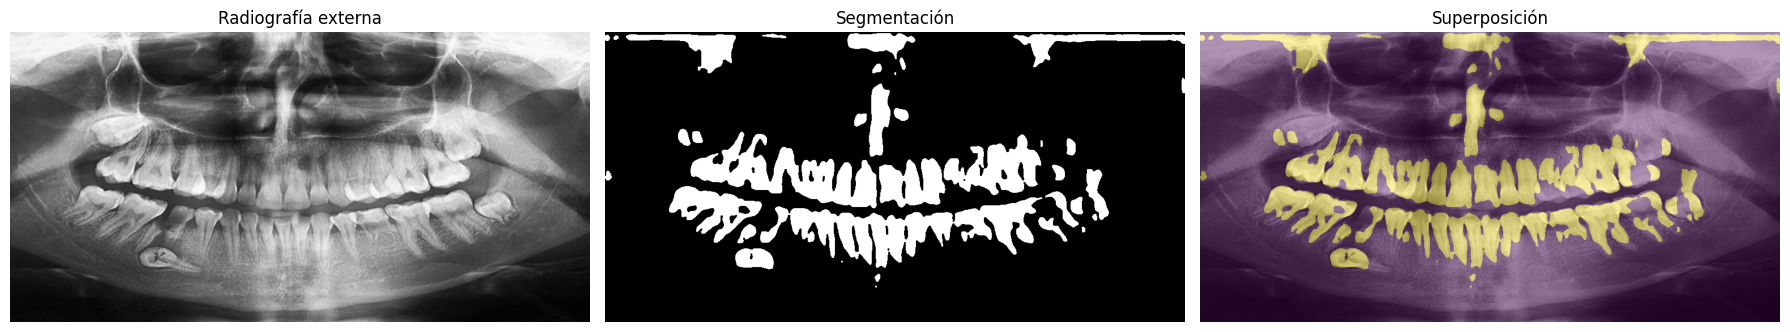

In [35]:
# Visualización de validación externa
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image_resized, cmap="gray")
plt.title("Radiografía externa")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(pred_mask.squeeze(), cmap="gray")
plt.title("Segmentación")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image_resized, cmap="gray")
plt.imshow(pred_mask.squeeze(), alpha=0.4)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "validacion_externa.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Trabajo futuro

Como trabajo futuro se propone:

- Incrementar el tamaño y diversidad del dataset.
- Realizar validación multicéntrica con radiografías de diferentes equipos.
- Evaluar arquitecturas más avanzadas como Attention U-Net y U-Net++.
- Comparar el desempeño contra modelos basados en Transformers.
- Extender el sistema hacia la clasificación automática de anomalías dentales.
- Optimizar el tiempo de inferencia para aplicaciones clínicas o educativas.